# NFL 4th-Down Decision Agent

This notebook explores historical play-by-play data to learn a data-driven policy for 4th-down decisions (punt, field goal attempt, or go for it).

## Notebook Roadmap

1. Environment checks and utilities.
2. Download and cache play-by-play data from the NFLVerse.
3. Filter 4th-down situations and build decision labels.
4. Explore historical tendencies and outcomes.
5. Engineer features for modeling.
6. Train baseline classifiers and evaluate performance.
7. Outline next steps toward reinforcement-learning style agents.

In [3]:
# Core imports and environment sanity checks
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from nfl_data_py import import_pbp_data

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier


In [4]:
# Project paths and configuration
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURE_DIR = PROJECT_ROOT / 'reports' / 'figures'

for path in [DATA_DIR, RAW_DIR, PROCESSED_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEASONS = list(range(2018, 2024))  # Adjust as desired
SEED = 42
np.random.seed(SEED)

In [5]:
# Data loading helpers
def load_pbp(seasons, cache_dir=RAW_DIR):
    """Return concatenated play-by-play data for the requested seasons."""
    frames = []
    for season in seasons:
        cache_file = cache_dir / f'pbp_{season}.parquet'
        if cache_file.exists():
            df = pd.read_parquet(cache_file)
            print(f'Loaded season {season} from cache ({cache_file})')
        else:
            print(f'Downloading play-by-play for {season}...')
            df = import_pbp_data([season])
            cache_file.parent.mkdir(parents=True, exist_ok=True)
            df.to_parquet(cache_file, index=False)
            print(f'Saved to {cache_file}')
        frames.append(df)
    if not frames:
        raise ValueError('No data retrieved; check seasons list or network connection.')
    combined = pd.concat(frames, ignore_index=True)
    print(f'Combined shape: {combined.shape}')
    return combined

pbp = load_pbp(SEASONS)
pbp.head()

2018 done.
Downcasting floats.
Saved to /Users/benlin/prodprojects/football/data/raw/pbp_2018.parquet
2019 done.
Downcasting floats.
Saved to /Users/benlin/prodprojects/football/data/raw/pbp_2019.parquet
2020 done.
Downcasting floats.
Saved to /Users/benlin/prodprojects/football/data/raw/pbp_2020.parquet
2021 done.
Downcasting floats.
Saved to /Users/benlin/prodprojects/football/data/raw/pbp_2021.parquet
2022 done.
Downcasting floats.
Saved to /Users/benlin/prodprojects/football/data/raw/pbp_2022.parquet
2023 done.
Downcasting floats.
Saved to /Users/benlin/prodprojects/football/data/raw/pbp_2023.parquet
Combined shape: (291095, 397)


,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,None,None,None,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
1,37.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2,52.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
3,75.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,False,HITCH,ZONE_COVERAGE,COVER_3,NaN,NaN,NaN,NaN,NaN,NaN
4,104.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
pbp

,play_id,game_id,old_game_id_x,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
0,1.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,None,None,None,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
1,37.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
2,52.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
3,75.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,False,HITCH,ZONE_COVERAGE,COVER_3,NaN,NaN,NaN,NaN,NaN,NaN
4,104.0,2018_01_ATL_PHI,2018090600,PHI,ATL,REG,1,ATL,away,PHI,...,None,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291090,4791.0,2023_22_SF_KC,2024021100,KC,SF,POST,22,KC,home,SF,...,False,,ZONE_COVERAGE,COVER_2,Creed Humphrey;Nick Allegretti;Trey Smith;Patr...,Charvarius Ward;Deommodore Lenoir;Nick Bosa;Ch...,C;G;G;QB;RB;T;T;TE;TE;WR;WR,CB;CB;DE;DE;DT;DT;FS;FS;ILB;OLB;SS,52;73;65;15;10;79;74;87;83;11;4,7;2;97;92;91;90;31;33;54;48;27
291091,4813.0,2023_22_SF_KC,2024021100,KC,SF,POST,22,KC,home,SF,...,False,,,None,Creed Humphrey;Nick Allegretti;Trey Smith;Patr...,Charvarius Ward;Deommodore Lenoir;Nick Bosa;Ch...,C;G;G;QB;RB;T;T;TE;TE;TE;WR,CB;CB;DE;DE;DT;DT;FS;FS;ILB;OLB;SS,52;73;65;15;10;79;74;87;81;83;84,7;2;97;92;91;90;31;33;54;48;27
291092,4835.0,2023_22_SF_KC,2024021100,KC,SF,POST,22,KC,home,SF,...,False,SCREEN,ZONE_COVERAGE,COVER_4,Creed Humphrey;Nick Allegretti;Trey Smith;Patr...,Charvarius Ward;Deommodore Lenoir;Nick Bosa;Ch...,C;G;G;QB;RB;T;T;TE;WR;WR;WR,CB;CB;DE;DE;DT;DT;FS;FS;ILB;OLB;SS,52;73;65;15;10;79;74;87;84;11;4,7;2;97;92;98;99;31;33;54;48;27
291093,4860.0,2023_22_SF_KC,2024021100,KC,SF,POST,22,KC,home,SF,...,False,QUICK OUT,ZONE_COVERAGE,COVER_4,Creed Humphrey;Nick Allegretti;Trey Smith;Patr...,Charvarius Ward;Deommodore Lenoir;Nick Bosa;Ch...,C;G;G;QB;RB;T;T;TE;TE;WR;WR,CB;CB;DE;DE;DT;DT;FS;FS;ILB;OLB;SS,52;73;65;15;1;79;74;87;83;11;12,7;2;97;92;98;99;31;33;54;48;27


### Focus on 4th-Down Plays

We now isolate 4th-down situations with clear decision outcomes and derive a categorical label for each choice.

In [6]:
FOURTH_DOWN_TYPES = {'punt', 'field_goal', 'run', 'pass'}

def classify_decision(row):
    play_type = row['play_type']
    if play_type == 'punt':
        return 'punt'
    if play_type == 'field_goal':
        return 'field_goal'
    if play_type in {'run', 'pass'}:
        return 'go_for_it'
    return 'other'

fourth_down_df = (
    pbp.query('down == 4').copy()
)
fourth_down_df['decision'] = fourth_down_df.apply(classify_decision, axis=1)
fourth_down_df = fourth_down_df[fourth_down_df['decision'] != 'other']
print(f'Filtered 4th-down sample: {fourth_down_df.shape}')
fourth_down_df[['posteam', 'defteam', 'yardline_100', 'ydstogo', 'score_differential', 'decision']].head()

Filtered 4th-down sample: (23454, 398)


,posteam,defteam,yardline_100,ydstogo,score_differential,decision
12,ATL,PHI,1.0,1.0,0.0,go_for_it
16,PHI,ATL,92.0,4.0,0.0,punt
26,ATL,PHI,3.0,3.0,0.0,field_goal
35,PHI,ATL,65.0,18.0,-3.0,punt
40,ATL,PHI,89.0,19.0,3.0,punt


In [7]:
# Decision distribution
decision_counts = fourth_down_df['decision'].value_counts().sort_values(ascending=False)
decision_counts

punt          13390
field_goal     5762
go_for_it      4302
Name: decision, dtype: int64

/var/folders/xn/3prbnvtn4ylcnz9l42z8vnnr0000gn/T/ipykernel_49623/1798596355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decision_counts.index, y=decision_counts.values, ax=ax, palette='viridis')


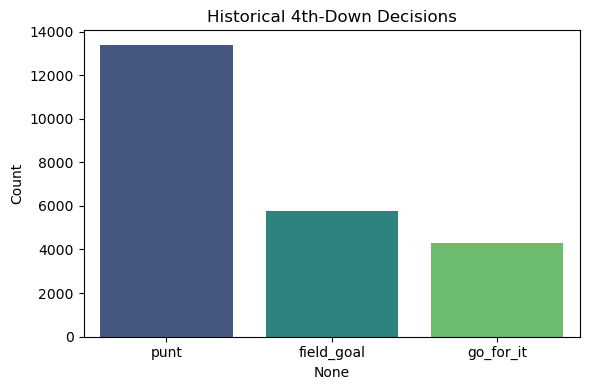

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=decision_counts.index, y=decision_counts.values, ax=ax, palette='viridis')
ax.set_ylabel('Count')
ax.set_title('Historical 4th-Down Decisions')
plt.tight_layout()
plt.show()

### Feature Engineering

We select informative contextual features and build a modeling dataset. Adjust the lists below as you iterate.

In [9]:
numeric_features = [
    'yardline_100',
    'ydstogo',
    'score_differential',
    'game_seconds_remaining',
    'half_seconds_remaining',
    'wp',
    'vegas_wp',
    'epa',
    'qb_epa',
    'def_wp',
    'kick_distance',
    'posteam_timeouts_remaining',
    'defteam_timeouts_remaining'
]

categorical_features = [
    'posteam',
    'defteam',
    'season',
    'week',
    'stadium',
    'roof',
    'surface',
    'posteam_type'
]

feature_cols = numeric_features + categorical_features
model_df = fourth_down_df[feature_cols + ['decision']].copy()

# Basic quality checks
missing = model_df.isna().mean().sort_values(ascending=False)
missing.head(10)

kick_distance                 0.183423
yardline_100                  0.000000
defteam_timeouts_remaining    0.000000
posteam_type                  0.000000
surface                       0.000000
roof                          0.000000
stadium                       0.000000
week                          0.000000
season                        0.000000
defteam                       0.000000
dtype: float64

In [10]:
# Train/validation split
X = model_df.drop(columns='decision')
y = model_df['decision']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train.shape, X_test.shape

((18763, 21), (4691, 21))

In [11]:
# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

In [12]:
# Baseline models
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=500, multi_class='multinomial')),
])

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        objective='multiclass',
        random_state=SEED,
        n_estimators=400,
        learning_rate=0.05,
        class_weight='balanced'
    )),
])

%%time
log_reg_pipeline.fit(X_train, y_train)
lgbm_pipeline.fit(X_train, y_train)

UsageError: Line magic function `%%time` not found.


In [13]:
# Evaluation helper
def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=False)
    print(title)
    print(report)
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'{title} — Confusion Matrix')
    plt.tight_layout()
    plt.show()

evaluate_model(log_reg_pipeline, X_test, y_test, 'Logistic Regression')
evaluate_model(lgbm_pipeline, X_test, y_test, 'LightGBM Classifier')

NotFittedError: Pipeline is not fitted yet.

In [ ]:
# Feature importances for the gradient boosting model
lgbm_model = lgbm_pipeline.named_steps['model']
ohe = lgbm_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
num_features = numeric_features
cat_features = list(ohe.get_feature_names_out(categorical_features))
all_features = num_features + cat_features

importances = pd.Series(lgbm_model.feature_importances_, index=all_features)
importances = importances.sort_values(ascending=False)
importances.head(20)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(20).iloc[::-1].plot(kind='barh', ax=ax)
ax.set_title('Top Feature Importances — LightGBM')
plt.tight_layout()
plt.show()

## Where to Go Next

- Calibrate probability outputs and map them to expected points for each decision.
- Incorporate situationally-aware cost functions (e.g., win probability swing).
- Simulate alternative decisions to estimate added win probability.
- Transition toward reinforcement learning by modeling drives or possessions as Markov Decision Processes (MDPs).